MODEL Training and Evaluation

In [1]:
!git clone https://github.com/mohammedumairuddin/EEEM073-AI-Sustainability-coursework.git

Cloning into 'EEEM073-AI-Sustainability-coursework'...
remote: Enumerating objects: 100, done.
remote: Counting objects: 100% (100/100), done.
remote: Compressing objects: 100% (93/93), done.
remote: Total 100 (delta 42), reused 3 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (100/100), 2.24 MiB | 3.06 MiB/s, done.
Resolving deltas: 100% (42/42), done.


In [2]:
!ls

EEEM073-AI-Sustainability-coursework  sample_data


In [3]:
cd EEEM073-AI-Sustainability-coursework/

/content/EEEM073-AI-Sustainability-coursework


In [4]:
!ls

datasets  models  notebooks  README.md	requirements.txt  results


In [5]:
%cd datasets

/content/EEEM073-AI-Sustainability-coursework/datasets


In [6]:
!ls

crop_production.csv


In [7]:
import pandas as pd

df = pd.read_csv("crop_production.csv")
df.head()

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0


In [8]:
import numpy as np

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

In [9]:
#Train test split of data for model training
from sklearn.model_selection import train_test_split

df["Yield"] = df["Production"] / df["Area"]

X = df.drop("Yield", axis=1)
y = df["Yield"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
print(df.dtypes)

State_Name        object
District_Name     object
Crop_Year          int64
Season            object
Crop              object
Area             float64
Production       float64
Yield            float64
dtype: object


In [11]:
print(X_train.select_dtypes(include="object").columns)

Index(['State_Name', 'District_Name', 'Season', 'Crop'], dtype='object')


In [12]:
#importing label encoder
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in ["State_Name","District_Name","Season","Crop"]:
    df[col] = le.fit_transform(df[col])

In [13]:
from sklearn.model_selection import train_test_split

X = df.drop("Yield", axis=1)
y = df["Yield"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
print(X_train.dtypes)

State_Name         int64
District_Name      int64
Crop_Year          int64
Season             int64
Crop               int64
Area             float64
Production       float64
dtype: object


In [15]:
X = df.drop("Yield", axis=1)
y = df["Yield"]

X = X.apply(pd.to_numeric, errors="coerce")

X = X.fillna(0)

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
#importing linear regression model
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [18]:
#importing Randomforest regression model
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [19]:
#Hyper parameter tuning
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators":[100,200],
    "max_depth":[5,10,15]
}

grid = GridSearchCV(
    RandomForestRegressor(),
    param_grid,
    cv=3,
    scoring="r2"
)

grid.fit(X_train,y_train)

best_model = grid.best_estimator_

In [20]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

In [21]:
def evaluate_model(y_true,y_pred):

    r2 = r2_score(y_true,y_pred)
    rmse = np.sqrt(mean_squared_error(y_true,y_pred))

    print("R2:",r2)
    print("RMSE:",rmse)

In [22]:
print("Linear Regression")
evaluate_model(y_test,y_pred_lr)

print("Random Forest")
evaluate_model(y_test,y_pred_rf)

Linear Regression
R2: 0.1687610290841639
RMSE: 670.582199367119
Random Forest
R2: 0.9516245855497497
RMSE: 161.7712801679476


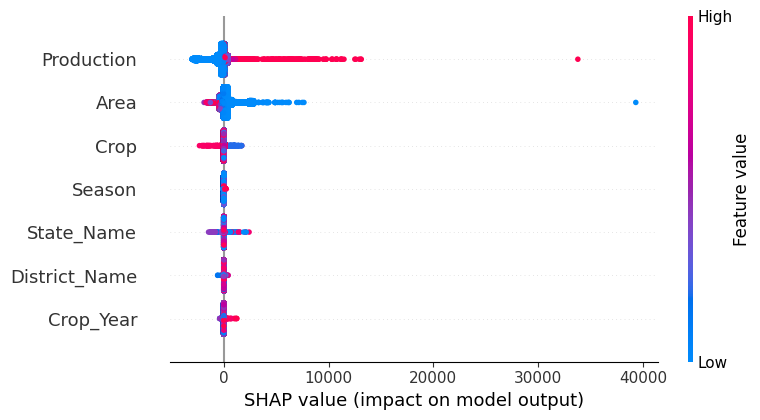

In [23]:
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

In [24]:
import time

start = time.time()
rf.fit(X_train,y_train)
end = time.time()

print("Training Time:", end-start)

Training Time: 149.5548801422119


In [25]:
import joblib
import os

# Create the 'models' directory if it doesn't exist
if not os.path.exists('models'):
    os.makedirs('models')

joblib.dump(rf,"models/rf_model.pkl")

['models/rf_model.pkl']

Part 4 - Model compression


In [26]:
from sklearn.feature_selection import SelectKBest,f_regression

selector = SelectKBest(score_func=f_regression,k=5)

X_new = selector.fit_transform(X_train,y_train)

In [27]:
compressed_rf = RandomForestRegressor(
    n_estimators=50,
    max_depth=5
)

compressed_rf.fit(X_train,y_train)

RandomForestRegressor(max_depth=5, n_estimators=50)

In [28]:
compressed_rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=5, n_estimators=50)

In [29]:
y_pred_compressed = compressed_rf.predict(X_test)

In [30]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred_compressed)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_compressed))

print("Compressed Model R2:", r2)
print("Compressed Model RMSE:", rmse)

Compressed Model R2: 0.8898976943602114
Compressed Model RMSE: 244.0547584162078


In [31]:
print("Baseline Model")
print("R2:", r2_score(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

print("\nCompressed Model")
print("R2:", r2_score(y_test, y_pred_compressed))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_compressed)))

Baseline Model
R2: 0.9516245855497497
RMSE: 161.7712801679476

Compressed Model
R2: 0.8898976943602114
RMSE: 244.0547584162078


In [32]:
import joblib
import os

joblib.dump(rf, "rf_model.pkl")
joblib.dump(compressed_rf, "compressed_rf.pkl")

size_original = os.path.getsize("rf_model.pkl") / (1024*1024)
size_compressed = os.path.getsize("compressed_rf.pkl") / (1024*1024)

print("Original Model Size:", size_original, "MB")
print("Compressed Model Size:", size_compressed, "MB")

Original Model Size: 9.602570533752441 MB
Compressed Model Size: 0.2188730239868164 MB


In [33]:
import time

start = time.time()
rf.predict(X_test)
end = time.time()

print("Original inference time:", end-start)

start = time.time()
compressed_rf.predict(X_test)
end = time.time()

print("Compressed inference time:", end-start)

Original inference time: 0.6426138877868652
Compressed inference time: 0.05660867691040039
